In [28]:
import zipfile
import os
zip_path = 'kedi_kopek_veri.zip'
extract_path = '/content/cats_dogs'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Çıkarılan klasörler:", os.listdir(extract_path))

cats_dir = '/content/cats_dogs/cats_set'
dogs_dir = '/content/cats_dogs/dogs_set'
print(f"Kedi görüntüsü: {len(os.listdir(cats_dir))}")
print(f"Köpek görüntüsü: {len(os.listdir(dogs_dir))}")

Çıkarılan klasörler: ['dogs_set', 'cats_set']
Kedi görüntüsü: 500
Köpek görüntüsü: 500


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler yüklendi. TensorFlow versiyonu:", tf.__version__)

Kütüphaneler yüklendi. TensorFlow versiyonu: 2.20.0


In [30]:
IMG_SIZE = 64
class_names = ['cat', 'dog']

X = []
y = []

for label, folder in enumerate(['cats_set', 'dogs_set']):
    folder_path = os.path.join('/content/cats_dogs', folder)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)

X = np.array(X)
y = np.array(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim veri seti şekli: {X_train.shape}")
print(f"Eğitim etiketleri şekli: {y_train.shape}")
print(f"Test veri seti şekli: {X_test.shape}")
print(f"Test etiketleri şekli: {y_test.shape}")

print(f"\nSınıf sayısı: {len(np.unique(y_train))}")
print(f"Sınıflar: {class_names}")

Eğitim veri seti şekli: (800, 64, 64, 3)
Eğitim etiketleri şekli: (800,)
Test veri seti şekli: (200, 64, 64, 3)
Test etiketleri şekli: (200,)

Sınıf sayısı: 2
Sınıflar: ['cat', 'dog']


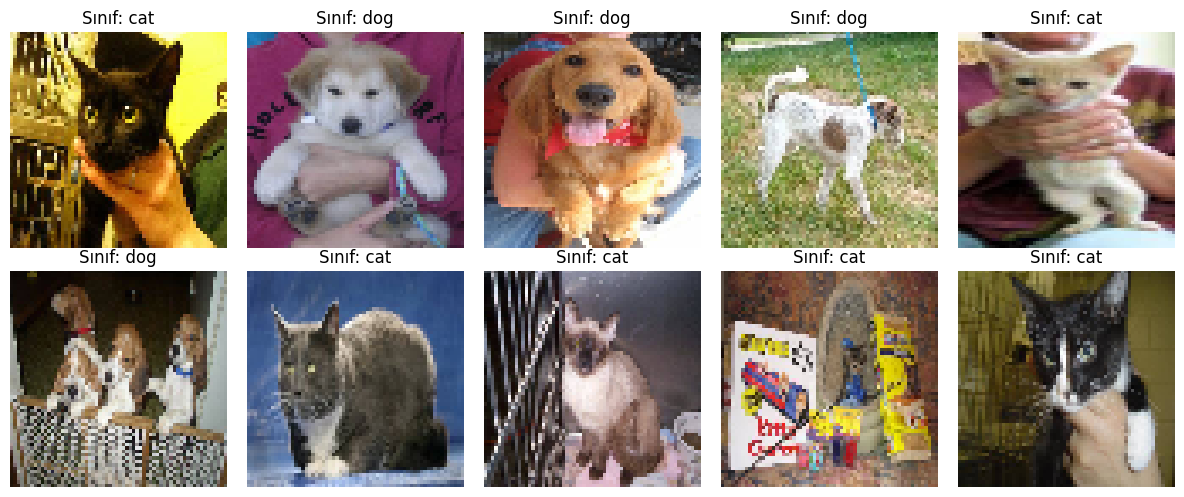

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

random_indices = np.random.choice(len(X), 10, replace=False)

for idx, ax in enumerate(axes):
    image = X[random_indices[idx]]
    label = y[random_indices[idx]]
    ax.imshow(image)
    ax.set_title(f"Sınıf: {class_names[label]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0


num_classes = len(class_names)
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

print(f"Eğitim seti: {X_train_normalized.shape}")
print(f"Test seti: {X_test_normalized.shape}")

Eğitim seti: (800, 64, 64, 3)
Test seti: (200, 64, 64, 3)


In [33]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

train_datagen.fit(X_train_normalized)
print("Veri augmentasyon hazırlandı.")

Veri augmentasyon hazırlandı.


In [34]:
model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,164,386 (8.26 MB)

 Trainable params: 2,163,746 (8.25 MB)

 Non-trainable params: 640 (2.50 KB)

In [35]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

print("CNN modeli eğitiliyor...")
start_time = time.time()

history = model_cnn.fit(
    X_train_normalized, y_train_categorical,
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nEğitim süresi: {training_time:.2f} saniye")

CNN modeli eğitiliyor...
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.5813 - loss: 1.0831 - val_accuracy: 0.5188 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6516 - loss: 0.7812 - val_accuracy: 0.4812 - val_loss: 1.6132 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7312 - loss: 0.5647 - val_accuracy: 0.4812 - val_loss: 3.0609 - learning_rate: 0.0010
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7516 - loss: 0.5728 - val_accuracy: 0.4812 - val_loss: 5.4473 - learning_rate: 0.0010
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7891 - loss: 0.4392 - val_accuracy: 0.4812 - val_loss: 7.9768 - learning_rate: 5.0000e-04
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8438 - loss: 0.3462 - val_accuracy: 0.4812 - val_loss: 9.0200 - learning_rate: 5.0000e-04

Eğitim süresi: 11.28 saniye


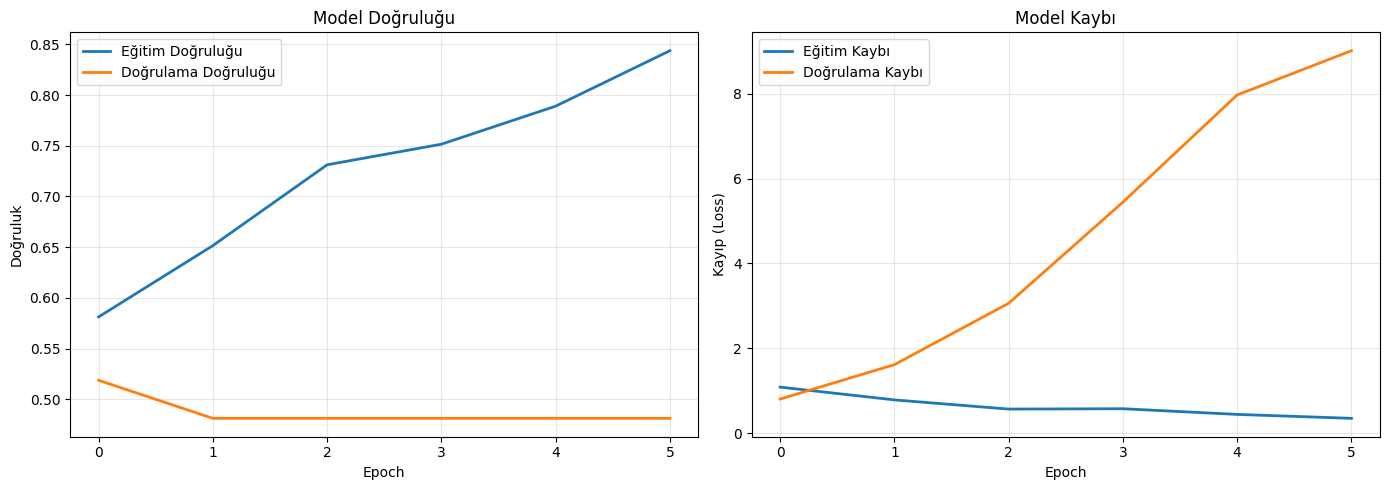

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Eğitim Doğruluğu', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Doğruluk')
axes[0].set_title('Model Doğruluğu')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Eğitim Kaybı', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Doğrulama Kaybı', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Kayıp (Loss)')
axes[1].set_title('Model Kaybı')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
y_pred_proba = model_cnn.predict(X_test_normalized, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("SINIFLANDIRMA RAPORU")
print("=" * 45)
print(classification_report(y_test, y_pred, target_names=class_names))

SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

         cat       0.51      0.98      0.67       100
         dog       0.75      0.06      0.11       100

    accuracy                           0.52       200
   macro avg       0.63      0.52      0.39       200
weighted avg       0.63      0.52      0.39       200



In [38]:
IMG_SIZE_TL = 96   # MobileNetV2 için biraz daha büyük boyut

# Görüntüleri yeniden boyutlandır
X_train_tl = tf.image.resize(X_train_normalized, (IMG_SIZE_TL, IMG_SIZE_TL)).numpy()
X_test_tl = tf.image.resize(X_test_normalized, (IMG_SIZE_TL, IMG_SIZE_TL)).numpy()

# Önceden eğitilmiş MobileNetV2'yi yükle
base_model = MobileNetV2(
    input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning modeli eğitiliyor...")
history_tl = model_tl.fit(
    X_train_tl, y_train_categorical,
    batch_size=32,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

test_loss_tl, test_acc_tl = model_tl.evaluate(X_test_tl, y_test_categorical, verbose=0)
print(f"\nTransfer Learning Test Doğruluğu: {test_acc_tl*100:.2f}%")

Transfer Learning modeli eğitiliyor...
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 231ms/step - accuracy: 0.8219 - loss: 0.4043 - val_accuracy: 0.8375 - val_loss: 0.4105
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9578 - loss: 0.1082 - val_accuracy: 0.8562 - val_loss: 0.4224
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9750 - loss: 0.0740 - val_accuracy: 0.8500 - val_loss: 0.4109
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9875 - loss: 0.0490 - val_accuracy: 0.8625 - val_loss: 0.4460
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9937 - loss: 0.0295 - val_accuracy: 0.8500 - val_loss: 0.4541
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9937 - loss: 0.0224 - val_accuracy: 0.8562 - val_loss: 0.4706
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9984 - loss: 0.0143 - val_accuracy: 0.8562 - val_loss: 0.4736
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 

In [39]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model başarıyla derlendi.")

Model başarıyla derlendi.


In [40]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7
)

print("Model eğitimi başlıyor...")
start_time = time.time()

history = model_cnn.fit(
    X_train_normalized, y_train_categorical,
    batch_size=32,
    epochs=40,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nEğitim süresi: {training_time:.2f} saniye")

Model eğitimi başlıyor...
Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.6062 - loss: 0.8894 - val_accuracy: 0.4812 - val_loss: 1.8327 - learning_rate: 0.0010
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6953 - loss: 0.7273 - val_accuracy: 0.4812 - val_loss: 7.4438 - learning_rate: 0.0010
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7656 - loss: 0.5506 - val_accuracy: 0.4812 - val_loss: 7.5829 - learning_rate: 0.0010
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7875 - loss: 0.4590 - val_accuracy: 0.4812 - val_loss: 6.0276 - learning_rate: 0.0010
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8141 - loss: 0.4208 - val_accuracy: 0.4812 - val_loss: 2.4436 - learning_rate: 0.0010
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8766 - loss: 0.3034 - val_accuracy: 0.4812 - val_loss: 6.5272 - learning_rate: 5.0000e-04
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 

In [41]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(factor=20/360.0),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2)
], name="data_augmentation_layer")

model_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,


    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),


    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),


    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),


    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_layer         │ (None, 64, 64, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 962,978 (3.67 MB)

 Trainable params: 961,314 (3.67 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [42]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7
)


model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model eğitimi başlıyor...")
start_time = time.time()

history = model_cnn.fit(
    X_train_normalized, y_train_categorical,
    batch_size=32,
    epochs=40,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

training_time = time.time() - start_time
print(f"\nEğitim süresi: {training_time:.2f} saniye")

Model eğitimi başlıyor...
Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.5391 - loss: 1.3088 - val_accuracy: 0.4812 - val_loss: 0.9788 - learning_rate: 0.0010
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5281 - loss: 1.1346 - val_accuracy: 0.4812 - val_loss: 1.2670 - learning_rate: 0.0010
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5688 - loss: 1.0712 - val_accuracy: 0.4812 - val_loss: 0.9095 - learning_rate: 0.0010
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5359 - loss: 1.0318 - val_accuracy: 0.4812 - val_loss: 1.2689 - learning_rate: 0.0010
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5797 - loss: 0.8799 - val_accuracy: 0.4812 - val_loss: 0.7954 - learning_rate: 0.0010
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5781 - loss: 0.8698 - val_accuracy: 0.4812 - val_loss: 0.7740 - learning_rate: 0.0010
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.59